# REQUIRED ARCHITECTURES FOR REFERENCE

## ORIGINAL CLIP ARCHITECTURE

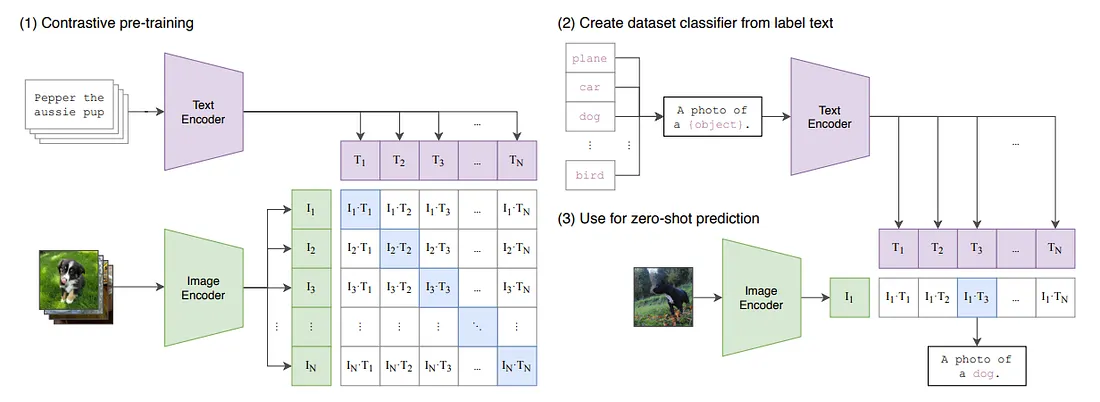

## VISION TRANSFORMER ARCHITECTURE

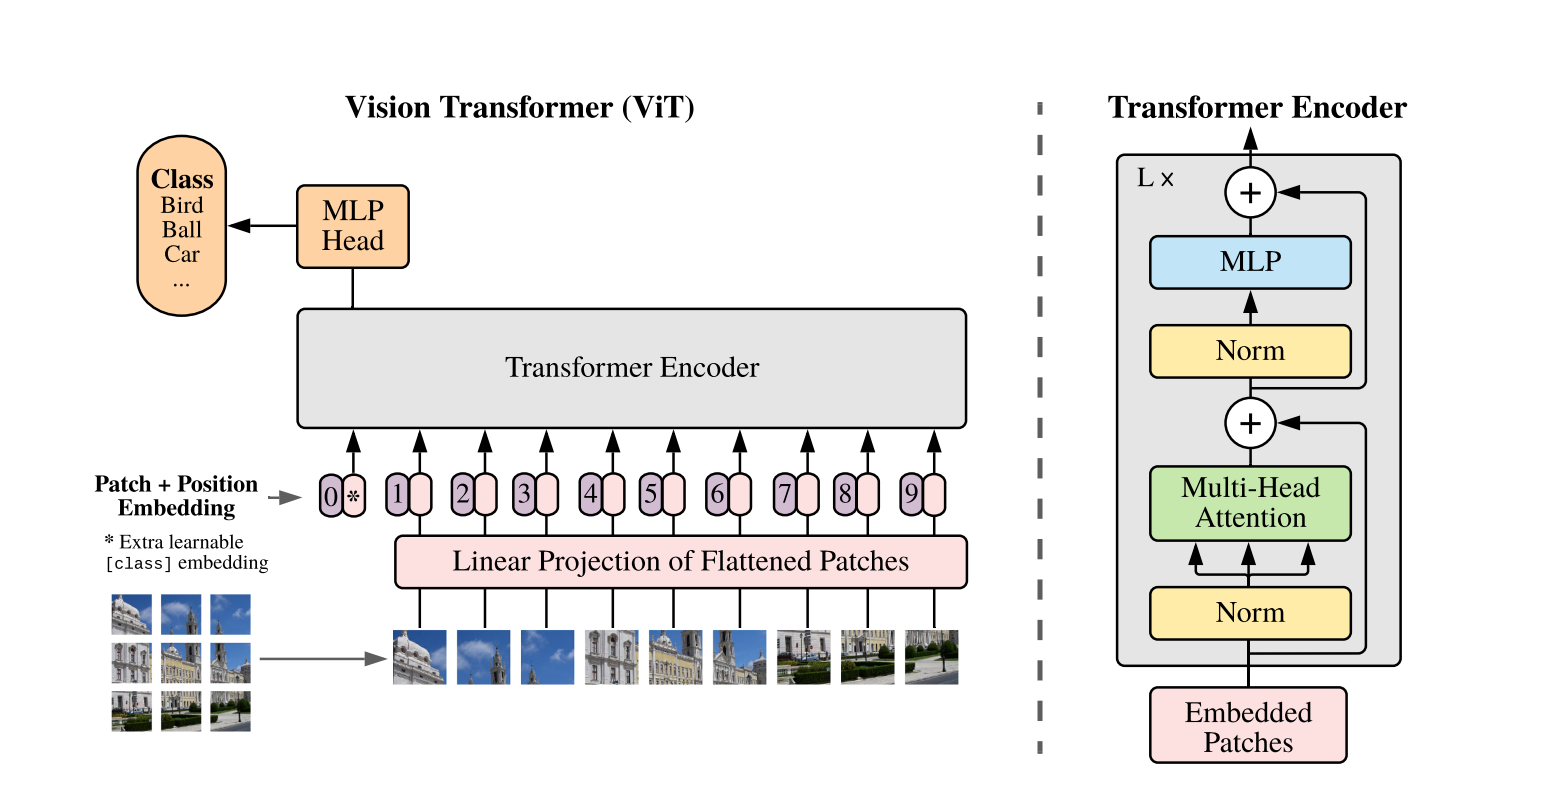

# IMPORTING REQUIRED MODULES AND LOADING THE DATASET

In [160]:
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets , transforms
from torch.utils.data import Dataset , DataLoader
from PIL import Image , ImageDraw
import matplotlib.pyplot as plt
import seaborn as sns

In [161]:
#Create Synthetic Data for the time being
colors = ['red' , 'blue' , 'green' , 'purple' , 'yellow' , 'orange' , 'pink' , 'brown' , 'gray']
shapes = ['square' , 'circle' , 'triangle']
positions = ['left' , 'center' , 'right' , 'top' , 'bottom' , 'top-left' , 'top-right' , 'bottom-left' , 'bottom-right']

In [162]:
#Create the Images
def draw_sample(color , shape , position , img_size = 32) :
  img = Image.new('RGB' , (img_size , img_size) , 'white' )
  draw = ImageDraw.Draw(img)

  margin = 6
  h=w= img_size - 2 * margin

  #Calculate x coordinates
  if 'left' in position :
    x0 = margin
    x1 = margin + w // 2
  elif 'top-left' in position :
    x0 = margin
    x1 = margin + w // 2
  elif 'bottom-left' in position :
    x0 = margin
    x1 = margin + w // 2
  elif 'right' in position :
    x0 = margin + w //2
    x1 = img_size - margin
  elif 'top-right' in position :
    x0 = margin + w //2
    x1 = img_size - margin
  elif 'bottom-right' in position :
    x0 = margin + w //2
    x1 = img_size - margin
  else :
    x0 = margin + w // 4
    x1 = margin + 3 * w // 4

  #Calculate y coordinates
  if 'top' in position :
    y0 = margin
    y1 = margin + h // 2
  elif 'top-left' in position :
    y0 = margin
    y1 = margin + h // 2
  elif 'top-right' in position :
    y0 = margin
    y1 = margin + h // 2
  elif 'bottom' in position :
    y0 = margin + h // 2
    y1 = img_size - margin
  elif 'bottom-left' in position :
    y0 = margin + h //2
    y1 = img_size - margin
  elif 'bottom-right' in position :
    y0 = margin + h //2
    y1 = img_size - margin
  else :
    y0 = margin + h // 4
    y1 = margin + 3 * w // 4

  
  if shape == 'square' :
    draw.rectangle([x0,y0,x1,y1] , fill = color , outline = 'black')
  elif shape == 'circle' :
    draw.ellipse([x0,y0,x1,y1] , fill = color , outline = 'black')
  else :
    draw.polygon([((x1+x0) // 2 , y0) , (x0 , y1) , (x1 , y1)] , fill = color , outline = 'black')
  return img

In [163]:
#Create the dataset class
class ShapesDataset(Dataset) :
  def __init__ (self) :
    self.images = []
    self.captions = []

    for c in colors :
      for s in shapes :
        for p in positions :
          img = draw_sample(c , s , p)
          cap = f"{c} {s} {p}" 
          self.images.append(torch.from_numpy(np.asarray(img)).permute(2,0,1).float()/255.0)
          self.captions.append(cap)

    self.vocab , self.word2idx = self.build_vocab(self.captions)

  def build_vocab(self , texts) :
    words = sorted({w for t in texts for w in t.split()})
    vocab = ['[CLS]'] + words
    w2i = {w : i for i , w in enumerate(vocab)}
    return vocab , w2i

  def encode_text(self , text) :
    toks = [self.word2idx['[CLS]']] + [self.word2idx[w] for w in text.split()]
    return torch.tensor(toks , dtype = torch.long)

  def __getitem__(self , idx) :
    return self.images[idx] , self.encode_text(self.captions[idx])

  def __len__ (self) :
    return len(self.images)

In [164]:
#Create the train and validation dataloaders

dataset = ShapesDataset()
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset , val_dataset = torch.utils.data.random_split(dataset , [train_size , val_size])
train_loader = DataLoader(train_dataset , batch_size = 12 , shuffle = True)
val_loader = DataLoader(train_dataset , batch_size = 12 , shuffle = False)


In [165]:
#Sanity check of sizes
img , label = next(iter(train_loader))
img.shape , label.shape

(torch.Size([12, 3, 32, 32]), torch.Size([12, 4]))

# MODEL CONFIGURATION AND MODEL CLASS

In [166]:
#MODEL CONFIGURATION
cfg = {"clip" : {
                    "temp" : 0.2 ,
                    "lr" : 3e-4 ,
                    "emb_dim" : 64 ,
                    "n_heads" : 4 ,
                    "n_layers" : 1 ,
                    "qkv_bias" : False
                } ,
       "img_encoder" : {
                          "patch_size" : 8 ,
                          "n_patches" : 16 ,
                          "input_channels" : 3
                       } ,
       "text_encoder" : {
                           "vocab_size" : 22 ,
                           "context_window" : 4
                        }
      }

In [167]:
class CLIPModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit_encoder = VisionTransformerEncoder()
        self.text_encoder = TextEncoder()

    def forward(self, images, captions):
        img_emb = self.vit_encoder(images)
        txt_emb = self.text_encoder(captions)

        return img_emb, txt_emb

# COMMON CLASSES

In [170]:
class MultiHeadAttention (nn.Module) :
    def __init__(self , d_in , d_out , n_heads ,  qkv_bias) :
        super().__init__()
        assert (d_out % n_heads == 0) , "d_out must be divisible by n_heads"
        self.d_out = d_out
        self.n_heads = n_heads
        self.head_dim = self.d_out // self.n_heads
        self.qkv_bias = qkv_bias

        self.W_query = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_key = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)
        self.W_value = nn.Linear(d_in , self.d_out , bias = self.qkv_bias)

    def forward(self , x) :

        batch_size , n_patches , d_in = x.shape
        keys , queries , values = self.W_key(x) , self.W_query(x) , self.W_value(x)


        keys = keys.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        queries = queries.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)
        values = values.view(batch_size , n_patches , self.n_heads , self.head_dim).transpose(1,2)

        attn_scores = queries @ keys.transpose(2 , 3)
        attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5 , dim = -1)

        context_vec = attn_weights @ values

        context_vec = context_vec.transpose(1,2)
        context_vec = context_vec.contiguous().view(batch_size , n_patches , self.d_out)

        return context_vec

In [171]:
class GeLU(nn.Module) :
    def __init__(self) :
        super().__init__()

    def forward(self , x) :
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

In [172]:
class LayerNorm (nn.Module) :
    def __init__(self) :
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(cfg["clip"]["emb_dim"]))
        self.shift = nn.Parameter(torch.zeros(cfg["clip"]["emb_dim"]))
    def forward(self , x) :
        mean = torch.mean(x , dim = - 1 , keepdim = True)
        std = torch.std(x , dim = - 1 , keepdim = True)

        x = (x - mean) / std

        return self.scale * x + self.shift

# VISION TRANSFORMER ENCODER CLASS AND ITS COMPONENTS

In [168]:
class VisionTransformerEncoder(nn.Module) :
    def __init__ (self) :
        super().__init__()
        self.img_embedding = PatchEmbedding() #
        self.cls_token = nn.Parameter(torch.randn(1 , 1 , cfg["clip"]["emb_dim"])) 
        self.pos_embedding = nn.Parameter(torch.randn(1 , cfg["img_encoder"]["n_patches"] + 1 , cfg["clip"]["emb_dim"]))
                                         
        self.trf_blocks = nn.Sequential(*[Transformer() for _ in range (cfg["clip"]["n_layers"])]) #
        self.linear = nn.Linear(cfg["clip"]["emb_dim"] , cfg["clip"]["emb_dim"])
        self.layer_norm = LayerNorm() #
        

    def forward(self , x) :
        b = x.size(0)
        x = self.img_embedding(x)
        class_token = self.cls_token.expand(b , - 1 , - 1)
        x = torch.cat([class_token , x] , dim = 1)
        x = x + self.pos_embedding
        x = self.trf_blocks(x)
        x = x[: , 0]
        x = F.normalize(self.layer_norm(x) , dim = - 1)
        return x
        

In [169]:
class PatchEmbedding(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.conv = nn.Conv2d(cfg["img_encoder"]["input_channels"] ,
                              cfg["clip"]["emb_dim"] ,
                              kernel_size = cfg["img_encoder"]["patch_size"] ,
                              stride = cfg["img_encoder"]["patch_size"]
                             )
    def forward(self , x) :
        x = self.conv(x)
        x = x.flatten(2).transpose(1 , 2)
        return x

In [173]:
class EncoderMLP(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.linear_1 = nn.Linear(cfg["clip"]["emb_dim"] , 4 * cfg["clip"]["emb_dim"])
        self.gelu = GeLU()
        self.linear_2 = nn.Linear(4 * cfg["clip"]["emb_dim"] , cfg["clip"]["emb_dim"])

    def forward(self , x) :

        x = self.linear_1(x)
        x=self.gelu(x)
        x=self.linear_2(x)

        return x

In [174]:
class Transformer(nn.Module) :
    def __init__(self) :
        super().__init__()
        self.pre_layer_norm_1 = LayerNorm()
        self.attention = MultiHeadAttention(d_in = cfg["clip"]["emb_dim"],
                                            d_out = cfg["clip"]["emb_dim"],
                                            n_heads = cfg["clip"]["n_heads"],
                                            qkv_bias = cfg["clip"]["qkv_bias"]
                                           )
        self.pre_layer_norm_2 = LayerNorm()
        self.mlp = EncoderMLP()

    def forward(self , x) :
        shortcut = x
        x = self.pre_layer_norm_1(x)
        x = self.attention(x)
        x = x + shortcut

        shortcut = x
        x = self.pre_layer_norm_2(x)
        x = self.mlp(x)
        x = x + shortcut
        return x                                            

# TEXT ENCODER CLASS AND ITS COMPONENTS

In [175]:
class TextEncoder(nn.Module) :
  def __init__ (self , vocab_size = cfg["text_encoder"]["vocab_size"] , emb_dim = cfg["clip"]["emb_dim"] , n_heads = cfg["clip"]["emb_dim"] , context_window = cfg["text_encoder"]["context_window"]) :
    super().__init__()
    self.token_embedding = nn.Embedding(vocab_size , emb_dim)
    self.position_embedding = nn.Embedding(context_window , emb_dim)
    self.attention = MultiHeadAttention(d_in = emb_dim,
                                        d_out = emb_dim,
                                        n_heads = n_heads,
                                        qkv_bias = cfg["clip"]["qkv_bias"]
                                        )
    self.projection = nn.Linear(emb_dim , emb_dim)
    self.norm = LayerNorm()

  def forward(self , x) :
    N , L = x.shape
    pos_ids = torch.arange(L , device = x.device).unsqueeze(0).expand(N , L)
    x = self.token_embedding(x) + self.position_embedding(pos_ids)
    x = self.attention(x)
    x = x[:,0]
    x = self.projection(x)
    x= F.normalize(self.norm(x) , dim = - 1)

    return x

# TRAINING AND EVALUATING MODEL

In [182]:
# Defining the Loss Function
def clip_loss(img_emb, txt_emb, temperature=cfg["clip"]["temp"]):

    img_emb = F.normalize(img_emb, dim=-1)
    txt_emb = F.normalize(txt_emb, dim=-1)

    logits = img_emb @ txt_emb.T
    logits = logits / temperature

    targets = torch.arange(
        logits.size(0),
        device=logits.device
    )

    loss_i = F.cross_entropy(logits, targets)
    loss_t = F.cross_entropy(logits.T, targets)

    return (loss_i + loss_t) / 2

In [187]:
# Training Loop

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 20
train_losses = []
val_losses = []
model = CLIPModel()
optimizer = torch.optim.AdamW(model.parameters() , lr = 3e-4)
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for images, captions in train_loader:
        images = images.to(device)
        captions = captions.to(device)
        optimizer.zero_grad()
        img_emb, txt_emb = model(images, captions)
        loss = clip_loss(img_emb, txt_emb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for images, captions in val_loader:

            images = images.to(device)
            captions = captions.to(device)
            img_emb, txt_emb = model(images, captions)

            loss = clip_loss(img_emb, txt_emb)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    print(
        f"Epoch [{epoch+1}/{epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Epoch [1/20] | Train Loss: 2.3865 | Val Loss: 2.3790
Epoch [2/20] | Train Loss: 2.3776 | Val Loss: 2.3747
Epoch [3/20] | Train Loss: 2.3722 | Val Loss: 2.3659
Epoch [4/20] | Train Loss: 2.3472 | Val Loss: 2.2842
Epoch [5/20] | Train Loss: 2.0332 | Val Loss: 1.3194
Epoch [6/20] | Train Loss: 0.9758 | Val Loss: 0.7469
Epoch [7/20] | Train Loss: 0.6745 | Val Loss: 0.6241
Epoch [8/20] | Train Loss: 0.5670 | Val Loss: 0.5582
Epoch [9/20] | Train Loss: 0.5312 | Val Loss: 0.5434
Epoch [10/20] | Train Loss: 0.5006 | Val Loss: 0.5056
Epoch [11/20] | Train Loss: 0.4583 | Val Loss: 0.4982
Epoch [12/20] | Train Loss: 0.4293 | Val Loss: 0.4635
Epoch [13/20] | Train Loss: 0.4807 | Val Loss: 0.4482
Epoch [14/20] | Train Loss: 0.4139 | Val Loss: 0.4229
Epoch [15/20] | Train Loss: 0.4103 | Val Loss: 0.4203
Epoch [16/20] | Train Loss: 0.3490 | Val Loss: 0.4018
Epoch [17/20] | Train Loss: 0.3695 | Val Loss: 0.3956
Epoch [18/20] | Train Loss: 0.3635 | Val Loss: 0.3831
Epoch [19/20] | Train Loss: 0.3855 | 

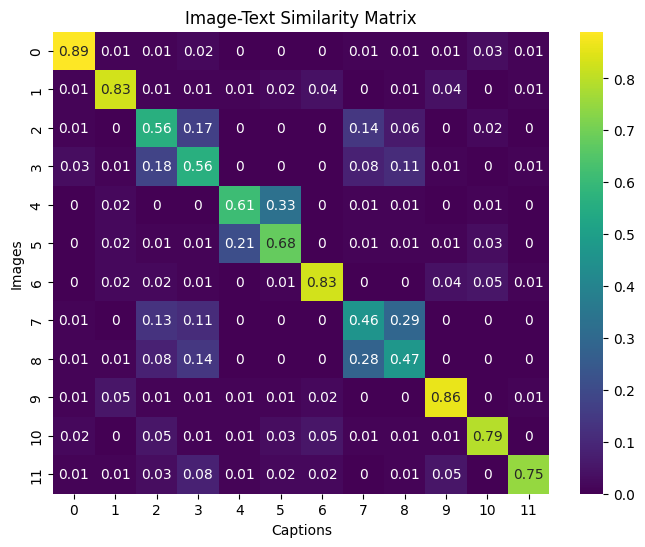

In [189]:
#Model Interpretation

model.eval()
images, tokens = next(iter(val_loader))
images = images.to(device)
tokens = tokens.to(device)
with torch.no_grad():
    img_emb = model.vit_encoder(images)
    txt_emb = model.text_encoder(tokens)

similarity = np.round((torch.softmax(img_emb@txt_emb.T/cfg["clip"]["temp"] , dim = 1)).numpy() , 2)
plt.figure(figsize=(8,6))

sns.heatmap(similarity,annot=True,cmap="viridis")
plt.xlabel("Captions")
plt.ylabel("Images")
plt.title("Image-Text Similarity Matrix")

plt.show()